In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

shrna_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv"
psp_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_PspCas13b_1nt.csv"
u1_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv"

shrna_df = pd.read_csv(shrna_in)
psp_df = pd.read_csv(psp_in)
u1_df = pd.read_csv(u1_in)

shrna_df["start_nt_NM_000371.3"] = pd.to_numeric(shrna_df["start_nt_NM_000371.3"], errors="coerce")
psp_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")
u1_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")

shrna_df = shrna_df[(shrna_df["start_nt_NM_000371.3"] >= 111) & (shrna_df["start_nt_NM_000371.3"] <= 709)].copy()
psp_df = psp_df[(psp_df["start_nt_NM_000371.3"] >= 111) & (psp_df["start_nt_NM_000371.3"] <= 697)].copy()
u1_df = u1_df[(u1_df["start_nt_NM_000371.3"] >= 111) & (u1_df["start_nt_NM_000371.3"] <= 704)].copy()

output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/Redo_Figure5"
os.makedirs(output_dir, exist_ok=True)

sigma_nt_default = 2
ttr_offset = 110
xticks_nt = [100, 200, 300, 400, 500, 600]
yticks_main = [-2, 0, 2, 4]
yticks_u1 = [-1, 0, 1, 2]
yticks_psp = [-1, 0, 1, 2, 3]
X_LABEL_TTR = "Guide RNA\nTTR transcript (NM_000371.4)"


def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

In [3]:
# ---------- U1CasRx Day 1 ----------
d_day1 = u1_df[["start_nt_NM_000371.3", "rep3_day1_Log2FC"]].copy()
d_day1["start_nt_NM_000371.3"] = pd.to_numeric(d_day1["start_nt_NM_000371.3"], errors="coerce")
d_day1["rep3_day1_Log2FC"]     = pd.to_numeric(d_day1["rep3_day1_Log2FC"], errors="coerce")
d_day1 = d_day1.dropna(subset=["start_nt_NM_000371.3", "rep3_day1_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day1 = d_day1["start_nt_NM_000371.3"].to_numpy() - 110
y_day1 = d_day1["rep3_day1_Log2FC"].to_numpy()

# ---------- U1CasRx Day 5 ----------
d_day5 = u1_df[["start_nt_NM_000371.3", "rep3_day5_Log2FC"]].copy()
d_day5["start_nt_NM_000371.3"] = pd.to_numeric(d_day5["start_nt_NM_000371.3"], errors="coerce")
d_day5["rep3_day5_Log2FC"]     = pd.to_numeric(d_day5["rep3_day5_Log2FC"], errors="coerce")
d_day5 = d_day5.dropna(subset=["start_nt_NM_000371.3", "rep3_day5_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day5 = d_day5["start_nt_NM_000371.3"].to_numpy() - 110
y_day5 = d_day5["rep3_day5_Log2FC"].to_numpy()

# ---------- PSP Cas13b (single timepoint) ----------
d_psp = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  
d_psp["start_nt_NM_000371.3"] = pd.to_numeric(d_psp["start_nt_NM_000371.3"], errors="coerce")
d_psp["Log2FC_mean"] = pd.to_numeric(d_psp["Log2FC_mean"], errors="coerce")
d_psp = d_psp.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_psp = d_psp["start_nt_NM_000371.3"].to_numpy() - 110
y_psp = d_psp["Log2FC_mean"].to_numpy()

# ---------- shRNA (single timepoint or combined) ----------
# Likewise, adapt the Log2FC column name to your shRNA mastersheet
d_shrna = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  # <-- replace "Log2FC" with actual shRNA column
d_shrna["start_nt_NM_000371.3"] = pd.to_numeric(d_shrna["start_nt_NM_000371.3"], errors="coerce")
d_shrna["Log2FC_mean"] = pd.to_numeric(d_shrna["Log2FC_mean"], errors="coerce")
d_shrna = d_shrna.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_shrna = d_shrna["start_nt_NM_000371.3"].to_numpy() - 110
y_shrna = d_shrna["Log2FC_mean"].to_numpy()

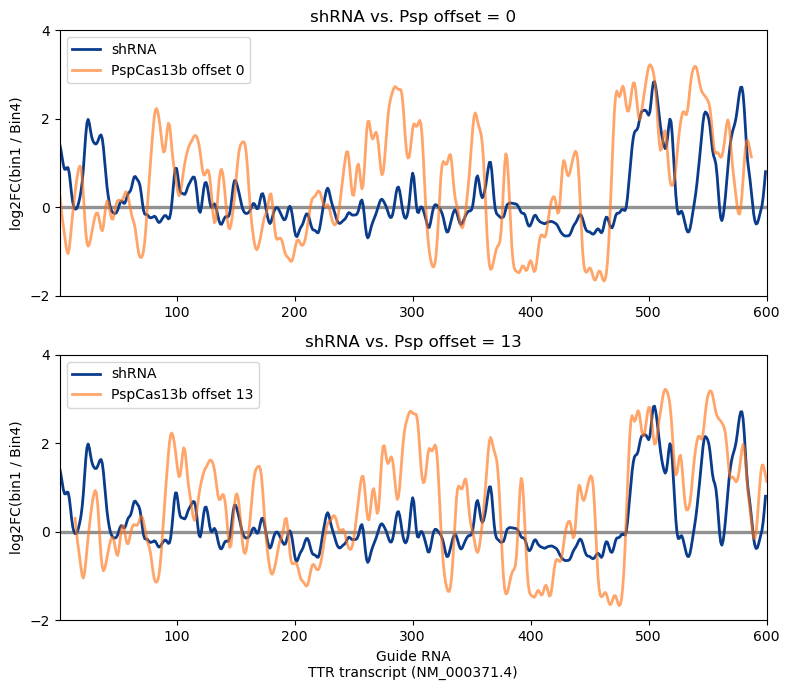

In [4]:
offsets = [0, 13]
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharey=True)

sigma_nt = sigma_nt_default  # in nt, shared for both datasets

for ax, offset in zip(axes, offsets):
    # shRNA
    d1 = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
    d1["Log2FC_mean"] = pd.to_numeric(d1["Log2FC_mean"], errors="coerce")
    d1 = d1.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
    x1 = d1["start_nt_NM_000371.3"].to_numpy() - 110
    y1 = d1["Log2FC_mean"].to_numpy()

    if len(x1) >= 4:
        x1_s, y1_s = gaussian_smooth_by_nt(x1, y1, sigma_nt)
        ax.plot(x1_s, y1_s, color="#0b3c8c", linewidth=2, label="shRNA")

    # PspCas13b
    d2 = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
    d2["Log2FC_mean"] = pd.to_numeric(d2["Log2FC_mean"], errors="coerce")
    d2 = d2.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
    x2 = d2["start_nt_NM_000371.3"].to_numpy() - 110 + offset
    y2 = d2["Log2FC_mean"].to_numpy()

    if len(x2) >= 4:
        x2_s, y2_s = gaussian_smooth_by_nt(x2, y2, sigma_nt)
        ax.plot(x2_s, y2_s, color="#FF7418A4", linewidth=2,
                label=f"PspCas13b offset {offset}")

    ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)
    ax.margins(x=0)
    ax.set_xticks([100, 200, 300, 400, 500, 600])
    ax.set_yticks([-2, 0, 2, 4])
    ax.set_ylabel("log2FC(bin1 / Bin4)")
    ax.set_title(f"shRNA vs. Psp offset = {offset}")
    ax.legend()
axes[-1].set_xlabel("Guide RNA\nTTR transcript (NM_000371.4)")

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "260723_Figure5_GraphL2_shRNAPsp_0_13.pdf"), format="pdf", bbox_inches="tight")
plt.show()